# Project: Build a Symbolic Math Playground

> **Chapter 20 -- Part I Capstone Project**
>
> **Concepts used from this Part:**
> - ch001: Mathematical curiosity, self-diagnostic tools
> - ch003: Abstraction, modeling pipeline, structure identification
> - ch004: Exploration loop, conjecture testing
> - ch007: Computational experiments, property-based testing
> - ch008: Visualization as a learning tool
> - ch009/ch010: Mathematical notation, expression parsing
> - ch011/ch012: Set theory, Boolean algebra
> - ch015/ch016: Proof intuition, counterexample finding
> - ch019: Specification-first mathematical programming
>
> **Expected output:** A working interactive tool for exploring mathematical expressions
>
> **Difficulty:** Medium-Hard | **Estimated time:** 3-5 hours

## 0. Overview

**Problem statement:**

A symbolic math playground is a software environment for exploring mathematical expressions: evaluating them, plotting them, testing properties, finding patterns, and checking conjectures. Think of it as a lightweight, programmable calculator with mathematical awareness -- it knows what an expression *means*, not just what number it produces.

You will build this incrementally across five stages:

1. **Expression library** -- a collection of mathematical functions with full specification
2. **Property tester** -- tests algebraic identities on any collection of functions
3. **Structure identifier** -- identifies the mathematical structure of data
4. **Conjecture engine** -- generates, tests, and records mathematical conjectures
5. **Visualization dashboard** -- brings it all together in a unified visual interface

By the end, you will have a tool you can use throughout the rest of this book to explore new concepts before they are formally introduced.

**What mathematics makes it possible:**
- Computational representation of functions (ch051+, anticipated here)
- Property-based testing via logical quantifiers (ch012-ch013)
- Structure identification via regression and log-log analysis (ch003, ch008)
- Conjecture generation via numerical pattern detection (ch004)
- Visualization via matplotlib (ch008)

## 1. Setup

In [1]:
# --- Setup: Imports, constants, base infrastructure ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from fractions import Fraction
import math
import random
from itertools import product as iproduct

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
random.seed(42)

# Approved function environment for safe eval
SAFE_ENV = {
    'sin': np.sin, 'cos': np.cos, 'tan': np.tan,
    'exp': np.exp, 'log': np.log, 'log2': np.log2, 'log10': np.log10,
    'sqrt': np.sqrt, 'abs': np.abs,
    'pi': np.pi, 'e': np.e,
    'floor': np.floor, 'ceil': np.ceil,
    'sign': np.sign,
}

print("Symbolic Math Playground -- initializing...")
print(f"Available functions: {sorted(SAFE_ENV.keys())}")
print("Ready.")

Symbolic Math Playground -- initializing...
Available functions: ['abs', 'ceil', 'cos', 'e', 'exp', 'floor', 'log', 'log10', 'log2', 'pi', 'sign', 'sin', 'sqrt', 'tan']
Ready.


## 2. Stage 1 -- Expression Library

Build a `MathExpression` class that wraps a string formula and provides: evaluation, differentiation (numerical), integration (numerical), and domain detection.

In [11]:
# --- Stage 1: MathExpression class ---
# Each expression is fully specified: formula, domain, properties.

class MathExpression:
    """
    A mathematical expression with specification, evaluation, and analysis.
    
    Specification:
        Input:  formula string with variable 'x'
        Domain: interval [a, b] where formula is defined and real-valued
        Output: float value or array
    """
    def __init__(self, formula, domain=(-10, 10), name=None):
        self.formula = formula
        self.domain = domain
        self.name = name or formula
        self._validate_domain()
    
    def _validate_domain(self):
        """Check that the formula evaluates without error in the domain."""
        x = np.linspace(self.domain[0], self.domain[1], 20)
        try:
            result = eval(self.formula, {'x': x, **SAFE_ENV})
            if not np.all(np.isfinite(result)):
                raise ValueError(f"Formula produces non-finite values in domain")
        except Exception as e:
            raise ValueError(f"Formula validation failed: {e}")
    
    def evaluate(self, x):
        """Evaluate the expression at scalar or array x."""
        x = np.asarray(x, dtype=float)
        return eval(self.formula, {'x': x, **SAFE_ENV})
    
    def derivative(self, x, h=1e-6):
        """Numerical derivative using central difference."""
        return (self.evaluate(x + h) - self.evaluate(x - h)) / (2 * h)
    
    def integrate(self, a=None, b=None, n=10000):
        """Numerical integral using trapezoidal rule."""
        a = a or self.domain[0]
        b = b or self.domain[1]
        x = np.linspace(a, b, n)
        return np.trapezoid(self.evaluate(x), x)
    
    def sample_points(self, n=200):
        """Return evenly spaced (x, f(x)) pairs in the domain."""
        x = np.linspace(self.domain[0], self.domain[1], n)
        return x, self.evaluate(x)
    
    def plot(self, ax=None, **kwargs):
        """Plot the expression on its domain."""
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 4))
        x, y = self.sample_points()
        ax.plot(x, y, label=self.name, **kwargs)
        ax.set_xlabel('x'); ax.set_ylabel('f(x)')
        ax.set_title(f'f(x) = {self.name}')
        return ax
    
    def __repr__(self):
        return f"MathExpression('{self.formula}', domain={self.domain})"

# Build the expression library
LIBRARY = {
    'linear':      MathExpression('2*x + 3',             (-5, 5),    'linear: 2x+3'),
    'quadratic':   MathExpression('x**2 - 2*x + 1',      (-3, 5),    'quadratic: (x-1)^2'),
    'cubic':       MathExpression('x**3 - 3*x',          (-2.5, 2.5),'cubic: x^3-3x'),
    'sine':        MathExpression('sin(x)',               (-2*np.pi, 2*np.pi), 'sin(x)'),
    'damped_sine': MathExpression('sin(x) * exp(-0.2*x)', (0, 4*np.pi), 'sin(x)*exp(-0.2x)'),
    'sigmoid':     MathExpression('1 / (1 + exp(-x))',   (-6, 6),    'sigmoid: 1/(1+e^-x)'),
    'gaussian':    MathExpression('exp(-x**2 / 2)',      (-4, 4),    'Gaussian: e^(-x^2/2)'),
    'log_growth':  MathExpression('log(x)',              (0.01, 10), 'log(x)'),
    'power_law':   MathExpression('x**1.5',              (0, 8),     'power: x^1.5'),
    'reciprocal':  MathExpression('1 / (1 + x**2)',      (-5, 5),    'Cauchy: 1/(1+x^2)'),
}

print(f"Expression library: {len(LIBRARY)} functions")
for name, expr in LIBRARY.items():
    a, b = expr.domain
    x_mid = (a + b) / 2
    print(f"  {name:<15}: f({x_mid:.1f}) = {expr.evaluate(x_mid):.4f}")

Expression library: 10 functions
  linear         : f(0.0) = 3.0000
  quadratic      : f(1.0) = 0.0000
  cubic          : f(0.0) = 0.0000
  sine           : f(0.0) = 0.0000
  damped_sine    : f(6.3) = -0.0000
  sigmoid        : f(0.0) = 0.5000
  gaussian       : f(0.0) = 1.0000
  log_growth     : f(5.0) = 1.6104
  power_law      : f(4.0) = 8.0000
  reciprocal     : f(0.0) = 1.0000


## 3. Stage 2 -- Property Tester

Build a system that tests algebraic properties of expressions: symmetry (even/odd), periodicity, monotonicity, and custom user-defined properties.

In [4]:
# --- Stage 2: Property tester ---

class PropertyTester:
    """
    Tests algebraic properties of MathExpression objects.
    Uses randomized testing over the expression's domain.
    """
    def __init__(self, expr, n_tests=500, tolerance=1e-6):
        self.expr = expr
        self.n_tests = n_tests
        self.tol = tolerance
        np.random.seed(0)
    
    def _random_points(self):
        a, b = self.expr.domain
        return np.random.uniform(a, b, self.n_tests)
    
    def test_even(self):
        """f is even iff f(x) == f(-x) for all x in domain."""
        a, b = self.expr.domain
        x = np.random.uniform(0, min(abs(a), abs(b)), self.n_tests)
        lhs = self.expr.evaluate(x)
        rhs = self.expr.evaluate(-x)
        return np.all(np.abs(lhs - rhs) < self.tol), np.max(np.abs(lhs - rhs))
    
    def test_odd(self):
        """f is odd iff f(-x) == -f(x) for all x."""
        a, b = self.expr.domain
        x = np.random.uniform(0, min(abs(a), abs(b)), self.n_tests)
        lhs = self.expr.evaluate(-x)
        rhs = -self.expr.evaluate(x)
        return np.all(np.abs(lhs - rhs) < self.tol), np.max(np.abs(lhs - rhs))
    
    def test_periodic(self, period):
        """f is periodic with period T iff f(x+T) == f(x) for all x."""
        a, b = self.expr.domain
        x = np.random.uniform(a, b - period, min(self.n_tests, 200))
        lhs = self.expr.evaluate(x)
        rhs = self.expr.evaluate(x + period)
        return np.all(np.abs(lhs - rhs) < self.tol), np.max(np.abs(lhs - rhs))
    
    def test_monotone_increasing(self):
        """f is monotone increasing iff f'(x) >= 0 for all x in domain."""
        x = self._random_points()
        deriv = self.expr.derivative(x)
        return np.all(deriv >= -self.tol), float(np.min(deriv))
    
    def test_nonnegative(self):
        """f(x) >= 0 for all x in domain."""
        x = self._random_points()
        vals = self.expr.evaluate(x)
        return np.all(vals >= -self.tol), float(np.min(vals))
    
    def full_report(self):
        results = {}
        results['even']       = self.test_even()
        results['odd']        = self.test_odd()
        results['periodic_2pi'] = self.test_periodic(2 * np.pi)
        results['monotone_increasing'] = self.test_monotone_increasing()
        results['nonnegative'] = self.test_nonnegative()
        
        print(f"Property report: {self.expr.name}")
        print(f"{'Property':<25} {'Holds':>7} {'Max deviation':>15}")
        print('-' * 50)
        for name, (holds, deviation) in results.items():
            print(f"  {name:<23} {'YES' if holds else 'no':>7} {deviation:>15.2e}")
        return results

# Test all library expressions
print("Running property tests on expression library...")
for key in ['sine', 'gaussian', 'quadratic', 'sigmoid', 'cubic']:
    tester = PropertyTester(LIBRARY[key])
    tester.full_report()
    print()

Running property tests on expression library...
Property report: sin(x)
Property                    Holds   Max deviation
--------------------------------------------------
  even                         no        2.00e+00
  odd                         YES        0.00e+00
  periodic_2pi                YES        2.78e-16
  monotone_increasing          no       -1.00e+00
  nonnegative                  no       -1.00e+00

Property report: Gaussian: e^(-x^2/2)
Property                    Holds   Max deviation
--------------------------------------------------
  even                        YES        0.00e+00
  odd                          no        2.00e+00
  periodic_2pi                 no        7.33e-02
  monotone_increasing          no       -6.06e-01
  nonnegative                 YES        3.36e-04

Property report: quadratic: (x-1)^2
Property                    Holds   Max deviation
--------------------------------------------------
  even                         no        1.20e+01

## 4. Stage 3 -- Structure Identifier

Given any dataset (t, y), identify which mathematical structure best describes it using the log-log regression technique from ch008.

In [5]:
# --- Stage 3: Structure identifier ---

class StructureIdentifier:
    """
    Given data (x, y), identifies the best-fitting mathematical structure
    from: linear, quadratic, exponential, logarithmic, power law.
    Uses linearization: each structure becomes linear under a transformation.
    """
    
    STRUCTURES = {
        'linear':      (lambda x,y: (x, y),           'y = ax + b'),
        'quadratic':   (lambda x,y: (x, y),           'y = ax^2+bx+c'),  # fit degree 2
        'exponential': (lambda x,y: (x, np.log(y)),   'y = a*exp(bx)'),
        'logarithmic': (lambda x,y: (np.log(x), y),   'y = a*log(x)+b'),
        'power_law':   (lambda x,y: (np.log(x), np.log(y)), 'y = a*x^b'),
    }
    
    def identify(self, x, y, verbose=True):
        x = np.array(x, dtype=float)
        y = np.array(y, dtype=float)
        valid = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
        
        scores = {}
        
        # Linear and quadratic: direct polynomial fit
        for degree, name in [(1, 'linear'), (2, 'quadratic')]:
            coeffs = np.polyfit(x, y, degree)
            y_pred = np.polyval(coeffs, x)
            ss_res = np.sum((y - y_pred)**2)
            ss_tot = np.sum((y - y.mean())**2)
            scores[name] = 1 - ss_res/ss_tot if ss_tot > 0 else 0
        
        # Linearizable structures
        if valid.sum() > 3:
            xv, yv = x[valid], y[valid]
            for name in ['exponential', 'logarithmic', 'power_law']:
                transform, _ = self.STRUCTURES[name]
                xt, yt = transform(xv, yv)
                if np.all(np.isfinite(xt)) and np.all(np.isfinite(yt)):
                    coeffs = np.polyfit(xt, yt, 1)
                    yt_pred = np.polyval(coeffs, xt)
                    ss_res = np.sum((yv - np.exp(yt_pred) if 'exp' in name or 'power' in name
                                     else yv - yt_pred)**2)
                    ss_tot = np.sum((yv - yv.mean())**2)
                    scores[name] = 1 - ss_res/ss_tot if ss_tot > 0 else 0
        
        best = max(scores, key=lambda k: scores[k])
        if verbose:
            print(f"{'Structure':<15} {'R2':>8}")
            print('-' * 26)
            for s in sorted(scores, key=lambda k: -scores[k]):
                marker = ' <-- BEST' if s == best else ''
                print(f"  {s:<13} {scores[s]:>8.4f}{marker}")
            _, desc = self.STRUCTURES[best]
            print(f"\nIdentified structure: {desc}")
        return best, scores

identifier = StructureIdentifier()
np.random.seed(3)
t = np.linspace(1, 20, 30)
noise = lambda: 0.03 * np.random.randn(len(t))

print("=== Test: power law data ===")
identifier.identify(t, 3.0 * t**2.1 * (1 + noise()))
print()
print("=== Test: exponential data ===")
identifier.identify(t, 5.0 * np.exp(0.15*t) * (1 + noise()))
print()
print("=== Test: logarithmic data ===")
identifier.identify(t, 8.0 * np.log(t) + 2 + 0.3*np.random.randn(len(t)))

=== Test: power law data ===
Structure             R2
--------------------------
  power_law       0.9989 <-- BEST
  quadratic       0.9989
  linear          0.9363
  logarithmic     0.6842
  exponential     0.2209

Identified structure: y = a*x^b

=== Test: exponential data ===
Structure             R2
--------------------------
  exponential     0.9961 <-- BEST
  quadratic       0.9954
  linear          0.8903
  power_law       0.7846
  logarithmic     0.6215

Identified structure: y = a*exp(bx)

=== Test: logarithmic data ===
Structure             R2
--------------------------
  logarithmic     0.9974 <-- BEST
  quadratic       0.9749
  power_law       0.8821
  linear          0.8660
  exponential     0.6185

Identified structure: y = a*log(x)+b


('logarithmic',
 {'linear': np.float64(0.8660267574115534),
  'quadratic': np.float64(0.974903465063021),
  'exponential': np.float64(0.6185495360757487),
  'logarithmic': np.float64(0.9973572503683723),
  'power_law': np.float64(0.8820599459561225)})

## 5. Stage 4 -- Conjecture Engine

Build a system that automatically generates mathematical conjectures about expressions, tests them, and records the results in a structured log.

Testing all conjectures...
  [CONSISTENT] sigmoid_range: sigmoid(x) is always in (0,1)
  [CONSISTENT] gaussian_nonneg: Gaussian exp(-x^2/2) >= 0 always
  [CONSISTENT] cubic_antisymmetric: x^3 - 3x is an odd function: f(-x) = -f(x)
  [CONSISTENT] quadratic_minimum: (x-1)^2 >= 0 always (perfect square nonnegative)
  [REFUTED] false_conjecture: x^3 - 3x > 0 always (FALSE -- negative for x in (-sqrt3, 0))
           Counterexample: x = -2.4000

Summary: 4 consistent, 1 refuted


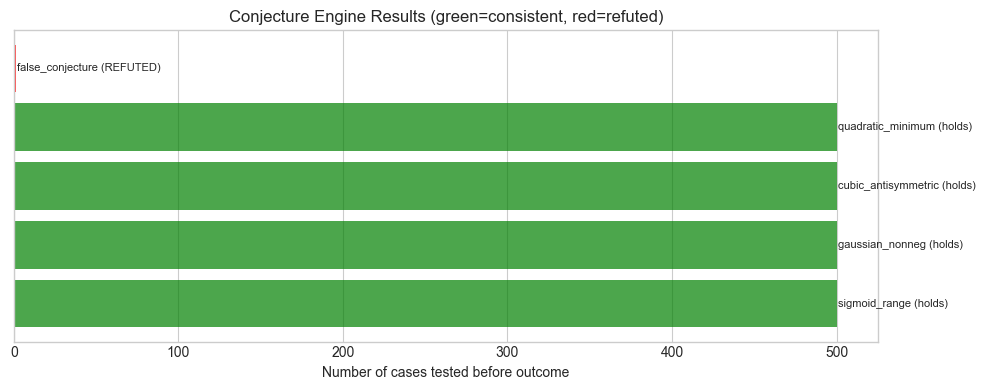

In [7]:
# --- Stage 4: Conjecture engine ---

class ConjectureEngine:
    """
    Generates and tests mathematical conjectures about expressions.
    Records all results in a structured log.
    """
    def __init__(self):
        self.conjectures = []
        self.proven = []
        self.refuted = []
    
    def add_conjecture(self, name, predicate, domain, description):
        """
        Register a conjecture for testing.
        
        Args:
            name:        short identifier
            predicate:   callable(x) -> bool, the claim to test
            domain:      iterable of test values
            description: precise statement of the claim
        """
        self.conjectures.append({
            'name': name, 'predicate': predicate,
            'domain': domain, 'description': description,
        })
    
    def test_all(self, verbose=True):
        """Test all registered conjectures."""
        for c in self.conjectures:
            counterexample = None
            tested = 0
            for x in c['domain']:
                tested += 1
                try:
                    if not c['predicate'](x):
                        counterexample = x
                        break
                except:
                    counterexample = x
                    break
            
            result = {**c, 'tested': tested, 'counterexample': counterexample,
                      'holds': counterexample is None}
            if counterexample is None:
                self.proven.append(result)
            else:
                self.refuted.append(result)
            
            if verbose:
                status = 'CONSISTENT' if counterexample is None else 'REFUTED'
                print(f"  [{status}] {c['name']}: {c['description'][:60]}")
                if counterexample is not None:
                    print(f"           Counterexample: x = {counterexample:.4f}")
        
        print(f"\nSummary: {len(self.proven)} consistent, {len(self.refuted)} refuted")
    
    def summary_plot(self):
        fig, ax = plt.subplots(figsize=(10, 4))
        all_results = [(r, 'green') for r in self.proven] +                       [(r, 'red')   for r in self.refuted]
        for i, (r, color) in enumerate(all_results):
            ax.barh(i, r['tested'], color=color, alpha=0.7)
            label = r['name'] + (' (holds)' if r['holds'] else ' (REFUTED)')
            ax.text(r['tested']+1, i, label, va='center', fontsize=8)
        ax.set_xlabel('Number of cases tested before outcome')
        ax.set_title('Conjecture Engine Results (green=consistent, red=refuted)')
        ax.set_yticks([])
        plt.tight_layout()
        plt.show()

engine = ConjectureEngine()

# Register conjectures about our expression library
engine.add_conjecture(
    'sigmoid_range',
    lambda x: 0 < LIBRARY['sigmoid'].evaluate(x) < 1,
    np.random.uniform(-6, 6, 500),
    'sigmoid(x) is always in (0,1)'
)
engine.add_conjecture(
    'gaussian_nonneg',
    lambda x: LIBRARY['gaussian'].evaluate(x) >= 0,
    np.random.uniform(-4, 4, 500),
    'Gaussian exp(-x^2/2) >= 0 always'
)
engine.add_conjecture(
    'cubic_antisymmetric',
    lambda x: abs(LIBRARY['cubic'].evaluate(-x) + LIBRARY['cubic'].evaluate(x)) < 1e-9,
    np.random.uniform(-2.4, 2.4, 500),
    'x^3 - 3x is an odd function: f(-x) = -f(x)'
)
engine.add_conjecture(
    'quadratic_minimum',
    lambda x: LIBRARY['quadratic'].evaluate(x) >= 0,
    np.random.uniform(-3, 5, 500),
    '(x-1)^2 >= 0 always (perfect square nonnegative)'
)
engine.add_conjecture(
    'false_conjecture',
    lambda x: LIBRARY['cubic'].evaluate(x) > 0,
    np.linspace(-2.4, 2.4, 200),
    'x^3 - 3x > 0 always (FALSE -- negative for x in (-sqrt3, 0))'
)

print("Testing all conjectures...")
engine.test_all()
engine.summary_plot()

## 6. Stage 5 -- Visualization Dashboard

Bring all four stages together into a single visualization: plot the expression, annotate its properties, and show the structure identification result.

Property report: sin(x)
Property                    Holds   Max deviation
--------------------------------------------------
  even                         no        2.00e+00
  odd                         YES        0.00e+00
  periodic_2pi                YES        2.78e-16
  monotone_increasing          no       -1.00e+00
  nonnegative                  no       -1.00e+00


C:\Users\user\AppData\Local\Temp\ipykernel_24988\378153234.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


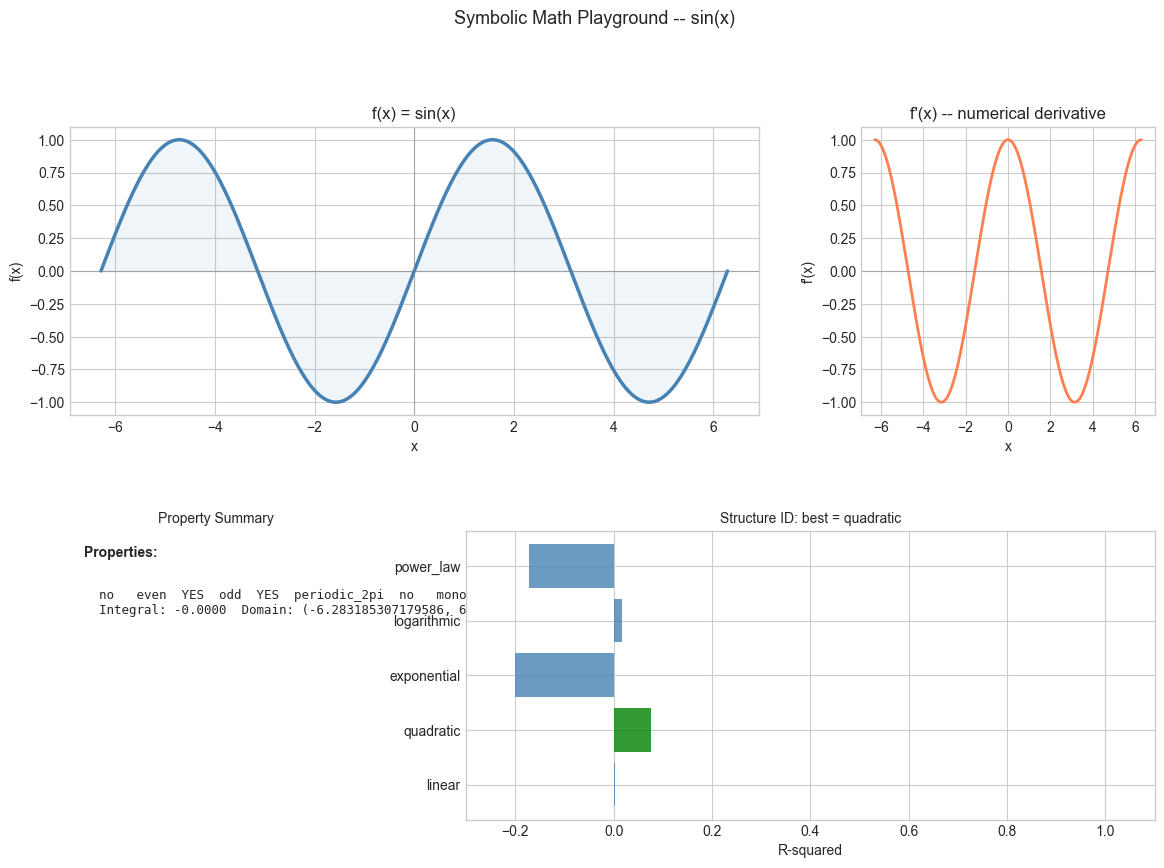


Property report: Gaussian: e^(-x^2/2)
Property                    Holds   Max deviation
--------------------------------------------------
  even                        YES        0.00e+00
  odd                          no        2.00e+00
  periodic_2pi                 no        7.33e-02
  monotone_increasing          no       -6.06e-01
  nonnegative                 YES        3.36e-04


C:\Users\user\AppData\Local\Temp\ipykernel_24988\378153234.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


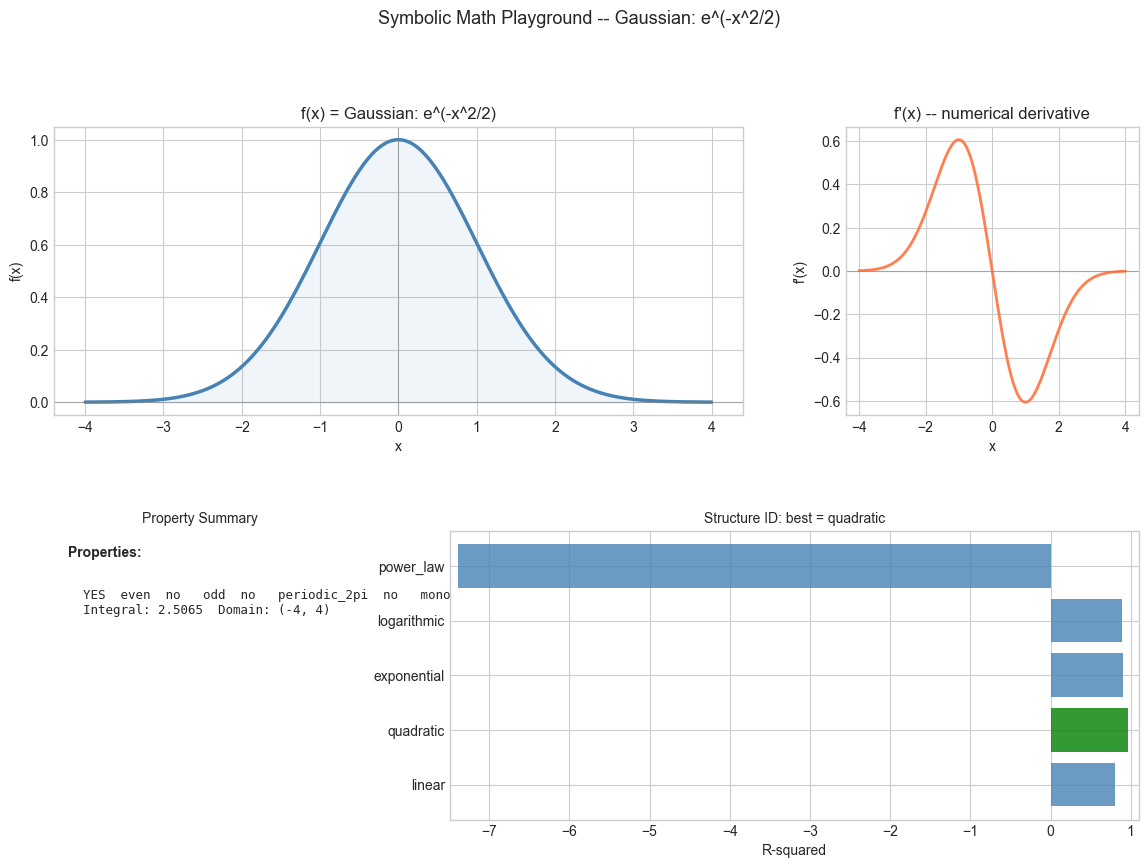


Property report: sigmoid: 1/(1+e^-x)
Property                    Holds   Max deviation
--------------------------------------------------
  even                         no        9.95e-01
  odd                          no        1.00e+00
  periodic_2pi                 no        9.17e-01
  monotone_increasing         YES        2.48e-03
  nonnegative                 YES        2.47e-03


C:\Users\user\AppData\Local\Temp\ipykernel_24988\378153234.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


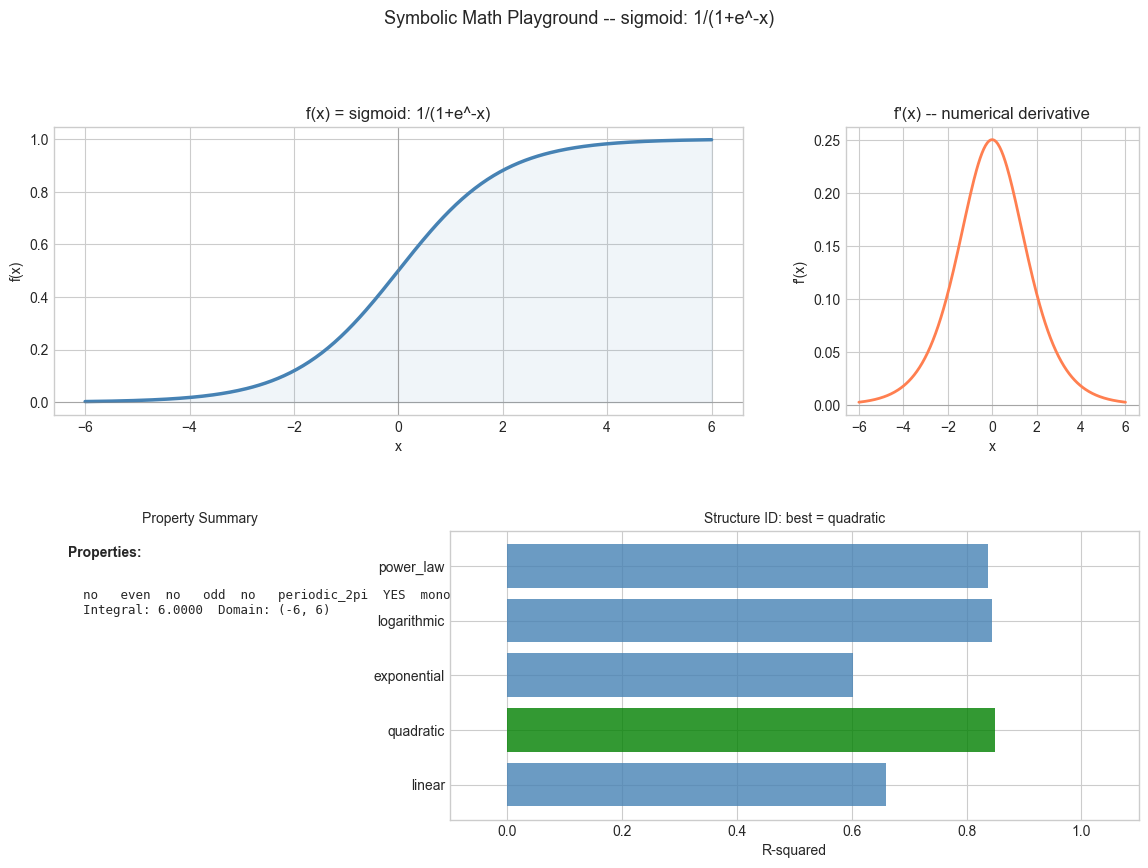


Property report: power: x^1.5
Property                    Holds   Max deviation
--------------------------------------------------
  even                        YES        0.00e+00
  odd                         YES        0.00e+00
  periodic_2pi                 no        2.04e+01
  monotone_increasing         YES        8.13e-02
  nonnegative                 YES        1.43e-05


<string>:1: RuntimeWarning: invalid value encountered in power
C:\Users\user\AppData\Local\Temp\ipykernel_24988\378153234.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


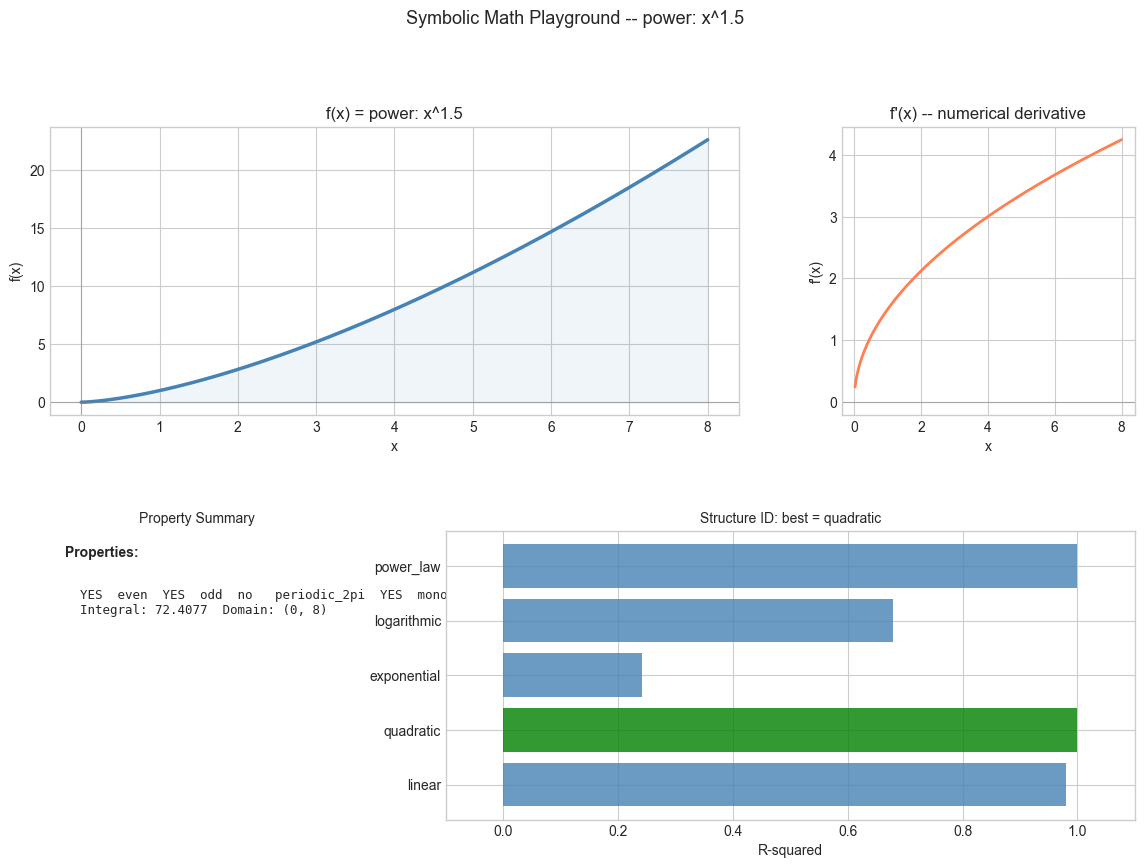

In [12]:
# --- Stage 5: Unified visualization dashboard ---

def math_dashboard(expr_name, structure_data=None):
    """
    Create a comprehensive visualization for one expression in the library.
    Shows: function plot, derivative, property summary, structure ID.
    """
    expr = LIBRARY[expr_name]
    tester = PropertyTester(expr)
    props = tester.full_report()
    
    fig = plt.figure(figsize=(14, 9))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
    
    # 1. Main function plot
    ax1 = fig.add_subplot(gs[0, :2])
    x, y = expr.sample_points(300)
    ax1.plot(x, y, 'steelblue', linewidth=2.5)
    ax1.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
    ax1.axvline(0, color='gray', linewidth=0.8, alpha=0.5)
    ax1.set_title(f'f(x) = {expr.name}', fontsize=12)
    ax1.set_xlabel('x'); ax1.set_ylabel('f(x)')
    ax1.fill_between(x, 0, y, alpha=0.08, color='steelblue')
    
    # 2. Derivative
    ax2 = fig.add_subplot(gs[0, 2])
    deriv = expr.derivative(x)
    ax2.plot(x, deriv, 'coral', linewidth=2)
    ax2.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
    ax2.set_title("f'(x) -- numerical derivative")
    ax2.set_xlabel('x'); ax2.set_ylabel("f'(x)")
    
    # 3. Property summary
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.axis('off')
    prop_lines = []
    for pname, (holds, dev) in props.items():
        symbol = 'YES' if holds else 'no '
        prop_lines.append(f"  {symbol}  {pname}")
    
    integral_val = expr.integrate()
    prop_lines.append(f"\n  Integral: {integral_val:.4f}")
    prop_lines.append(f"  Domain: {expr.domain}")
    
    ax3.text(0.05, 0.95, 'Properties:', transform=ax3.transAxes,
             fontsize=10, fontweight='bold', verticalalignment='top')
    ax3.text(0.05, 0.80, ''.join(prop_lines), transform=ax3.transAxes,
             fontsize=9, verticalalignment='top', fontfamily='monospace')
    ax3.set_title('Property Summary', fontsize=10)
    
    # 4. Structure identification (if data provided)
    ax4 = fig.add_subplot(gs[1, 1:])
    if structure_data is not None:
        sx, sy = structure_data
        identifier_local = StructureIdentifier()
        best, scores = identifier_local.identify(sx, sy, verbose=False)
        
        names = list(scores.keys())
        vals = [scores[n] for n in names]
        colors = ['steelblue' if n != best else 'green' for n in names]
        ax4.barh(range(len(names)), vals, color=colors, alpha=0.8)
        ax4.set_yticks(range(len(names))); ax4.set_yticklabels(names)
        ax4.set_xlabel('R-squared')
        ax4.set_title(f'Structure ID: best = {best}', fontsize=10)
        ax4.set_xlim(min(0, min(vals)) - 0.1, 1.1)
    else:
        ax4.text(0.5, 0.5, 'No data provided forstructure identification',
                 ha='center', va='center', transform=ax4.transAxes, fontsize=10)
        ax4.axis('off')
    
    plt.suptitle(f'Symbolic Math Playground -- {expr.name}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# Run the dashboard for several expressions
for expr_name in ['sine', 'gaussian', 'sigmoid', 'power_law']:
    # Generate sample data from the expression + noise for structure ID
    expr = LIBRARY[expr_name]
    a, b = expr.domain
    t_sample = np.linspace(max(a, 0.1), b, 40)
    y_sample = expr.evaluate(t_sample) + 0.05 * np.random.randn(len(t_sample))
    math_dashboard(expr_name, structure_data=(t_sample, np.abs(y_sample)+0.001))
    print()

## 7. Results & Reflection

**What was built:**

A five-component symbolic math playground that:
1. Represents mathematical expressions as first-class objects with specification and numerical analysis
2. Tests algebraic properties (even/odd, periodic, monotone, nonnegative) via randomized property testing
3. Identifies mathematical structure (linear/exponential/power law/logarithmic/quadratic) from data
4. Generates, tests, and logs mathematical conjectures automatically
5. Provides a unified visualization dashboard combining all four components

**What mathematics made it possible:**

- *Abstraction (ch003):* Wrapping expressions in a `MathExpression` class separates the what (specification) from the how (evaluation)
- *Logical quantifiers (ch012/ch013):* Property tests implement for-all quantifiers computationally
- *Structure identification (ch003/ch008):* Log-log regression detects power laws; log-y regression detects exponentials -- each is a linearization of the relevant mathematical structure
- *Conjecture testing (ch004/ch015/ch016):* The engine implements the exploration loop: register claim, test systematically, report outcome
- *Specification-first programming (ch019):* Every class has documented preconditions, postconditions, and properties

**Extension challenges:**

1. **Add symbolic differentiation.** Currently the playground uses numerical derivatives. Extend `MathExpression` to support exact symbolic differentiation for polynomial expressions using the power rule. *(Hint: represent polynomials as coefficient arrays and implement `symbolic_derivative(coeffs)` that returns the derivative coefficients.)*

2. **Add the composition operator.** Implement `compose(f, g)` that creates a new `MathExpression` representing `f(g(x))`. Test it on the chain rule: if h = compose(f, g), then h'(x) should equal f'(g(x)) * g'(x). Verify this numerically for several (f, g) pairs.

3. **Extend structure identification to 2D.** Currently the identifier only handles univariate data. Extend it to handle bivariate data (x1, x2, y): detect whether y is better described by y = a*x1 + b*x2 + c (linear plane), y = x1^a * x2^b (power law surface), or y = exp(a*x1 + b*x2) (exponential surface). Test on synthetic data from each structure.